In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

path = "Datasets/bank_customer_analytics.csv"
df = pd.read_csv(path)

print("First 10 rows:")
df.head(10)

print("\nColumns:")
df.columns

print("\nDataset Info:")
df.info()

# Check summary statistics
print("\nSummary Statistics:")
df.describe(include='all')


First 10 rows:

Columns:

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     3000 non-null   object 
 1   Age            2838 non-null   float64
 2   Gender         3000 non-null   object 
 3   MaritalStatus  3000 non-null   object 
 4   Income         2865 non-null   float64
 5   Savings        2854 non-null   float64
 6   CreditScore    2857 non-null   float64
 7   LoanAmount     2867 non-null   float64
 8   LoanStatus     3000 non-null   object 
 9   AccountType    3000 non-null   object 
 10  YearsWithBank  2713 non-null   float64
 11  Churn          3000 non-null   object 
dtypes: float64(6), object(6)
memory usage: 281.4+ KB

Summary Statistics:


,CustomerID,Age,Gender,MaritalStatus,Income,Savings,CreditScore,LoanAmount,LoanStatus,AccountType,YearsWithBank,Churn
count,3000,2838.000000,3000,3000,2865.000000,2854.000000,2857.000000,2867.000000,3000,3000,2713.000000,3000
unique,3000,NaN,4,4,NaN,NaN,NaN,NaN,3,4,NaN,2
top,C0001,NaN,female,single,NaN,NaN,NaN,NaN,approved,savings,NaN,no
freq,1,NaN,889,1216,NaN,NaN,NaN,NaN,1793,1236,NaN,2094
mean,NaN,39.048626,NaN,NaN,68293.193717,21483.882270,694.662233,34080.920823,NaN,NaN,6.883155,NaN
std,NaN,9.816456,NaN,NaN,19997.850070,20893.054327,68.907793,9972.978607,NaN,NaN,5.907284,NaN
min,NaN,25.000000,NaN,NaN,40000.000000,5000.000000,600.000000,20000.000000,NaN,NaN,1.000000,NaN
25%,NaN,35.000000,NaN,NaN,60000.000000,10000.000000,650.000000,30000.000000,NaN,NaN,2.000000,NaN
50%,NaN,35.000000,NaN,NaN,60000.000000,15000.000000,700.000000,30000.000000,NaN,NaN,5.000000,NaN
75%,NaN,45.000000,NaN,NaN,80000.000000,20000.000000,750.000000,40000.000000,NaN,NaN,10.000000,NaN


In [75]:
# 
# Check for missing values
print("\nMissing values per column:",df.isna().sum())
df.isna().sum()
df['Churn_numeric'] = df['Churn'].map({'no': 0, 'yes': 1})

numerical_cols = df.select_dtypes(include=['number']).columns

# Fill missing values for numerical columns with the median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
# df['Churn_numeric'] = df['Churn'].map({'no': 0, 'yes': 1})

#print isna.sum() after missing values
print("\nMissing values after fillna:\n",df.isna().sum())


Missing values per column: CustomerID         0
Age              162
Gender             0
MaritalStatus      0
Income           135
Savings          146
CreditScore      143
LoanAmount       133
LoanStatus         0
AccountType        0
YearsWithBank    287
Churn              0
dtype: int64

Missing values after fillna:
 CustomerID       0
Age              0
Gender           0
MaritalStatus    0
Income           0
Savings          0
CreditScore      0
LoanAmount       0
LoanStatus       0
AccountType      0
YearsWithBank    0
Churn            0
Churn_numeric    0
dtype: int64


Index(['Gender', 'MaritalStatus', 'LoanStatus', 'AccountType', 'Churn'], dtype='object')


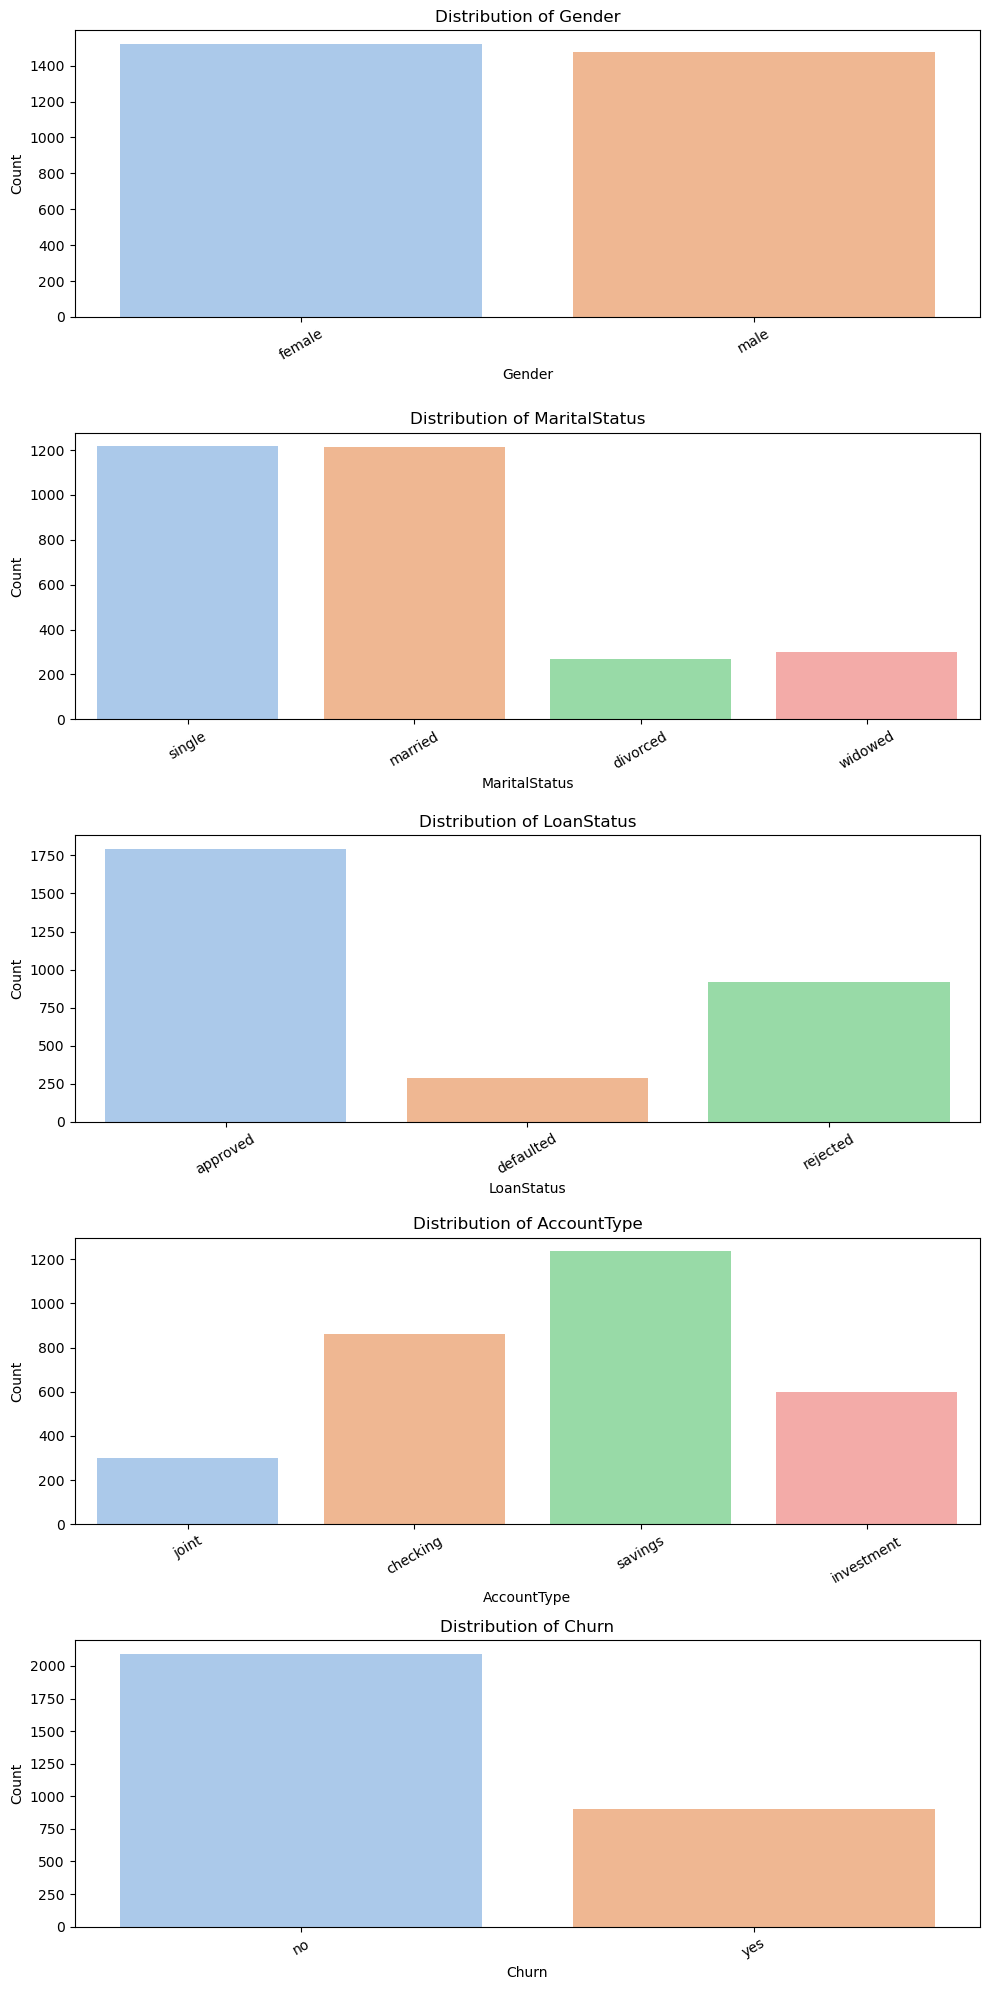

In [76]:
# Distributions of categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns.drop('CustomerID')
df[categorical_cols] = df[categorical_cols]
print(categorical_cols)

## WARNING gender has 4 values  instead of 2 due to character mismatch lower/upper case
df['Gender'] = df['Gender'].str.lower()

fig, axes = plt.subplots(nrows=len(categorical_cols), ncols=1, figsize=(10, 4 * len(categorical_cols)))

# Step 2: Loop and plot each feature in its own row
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='pastel', legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()


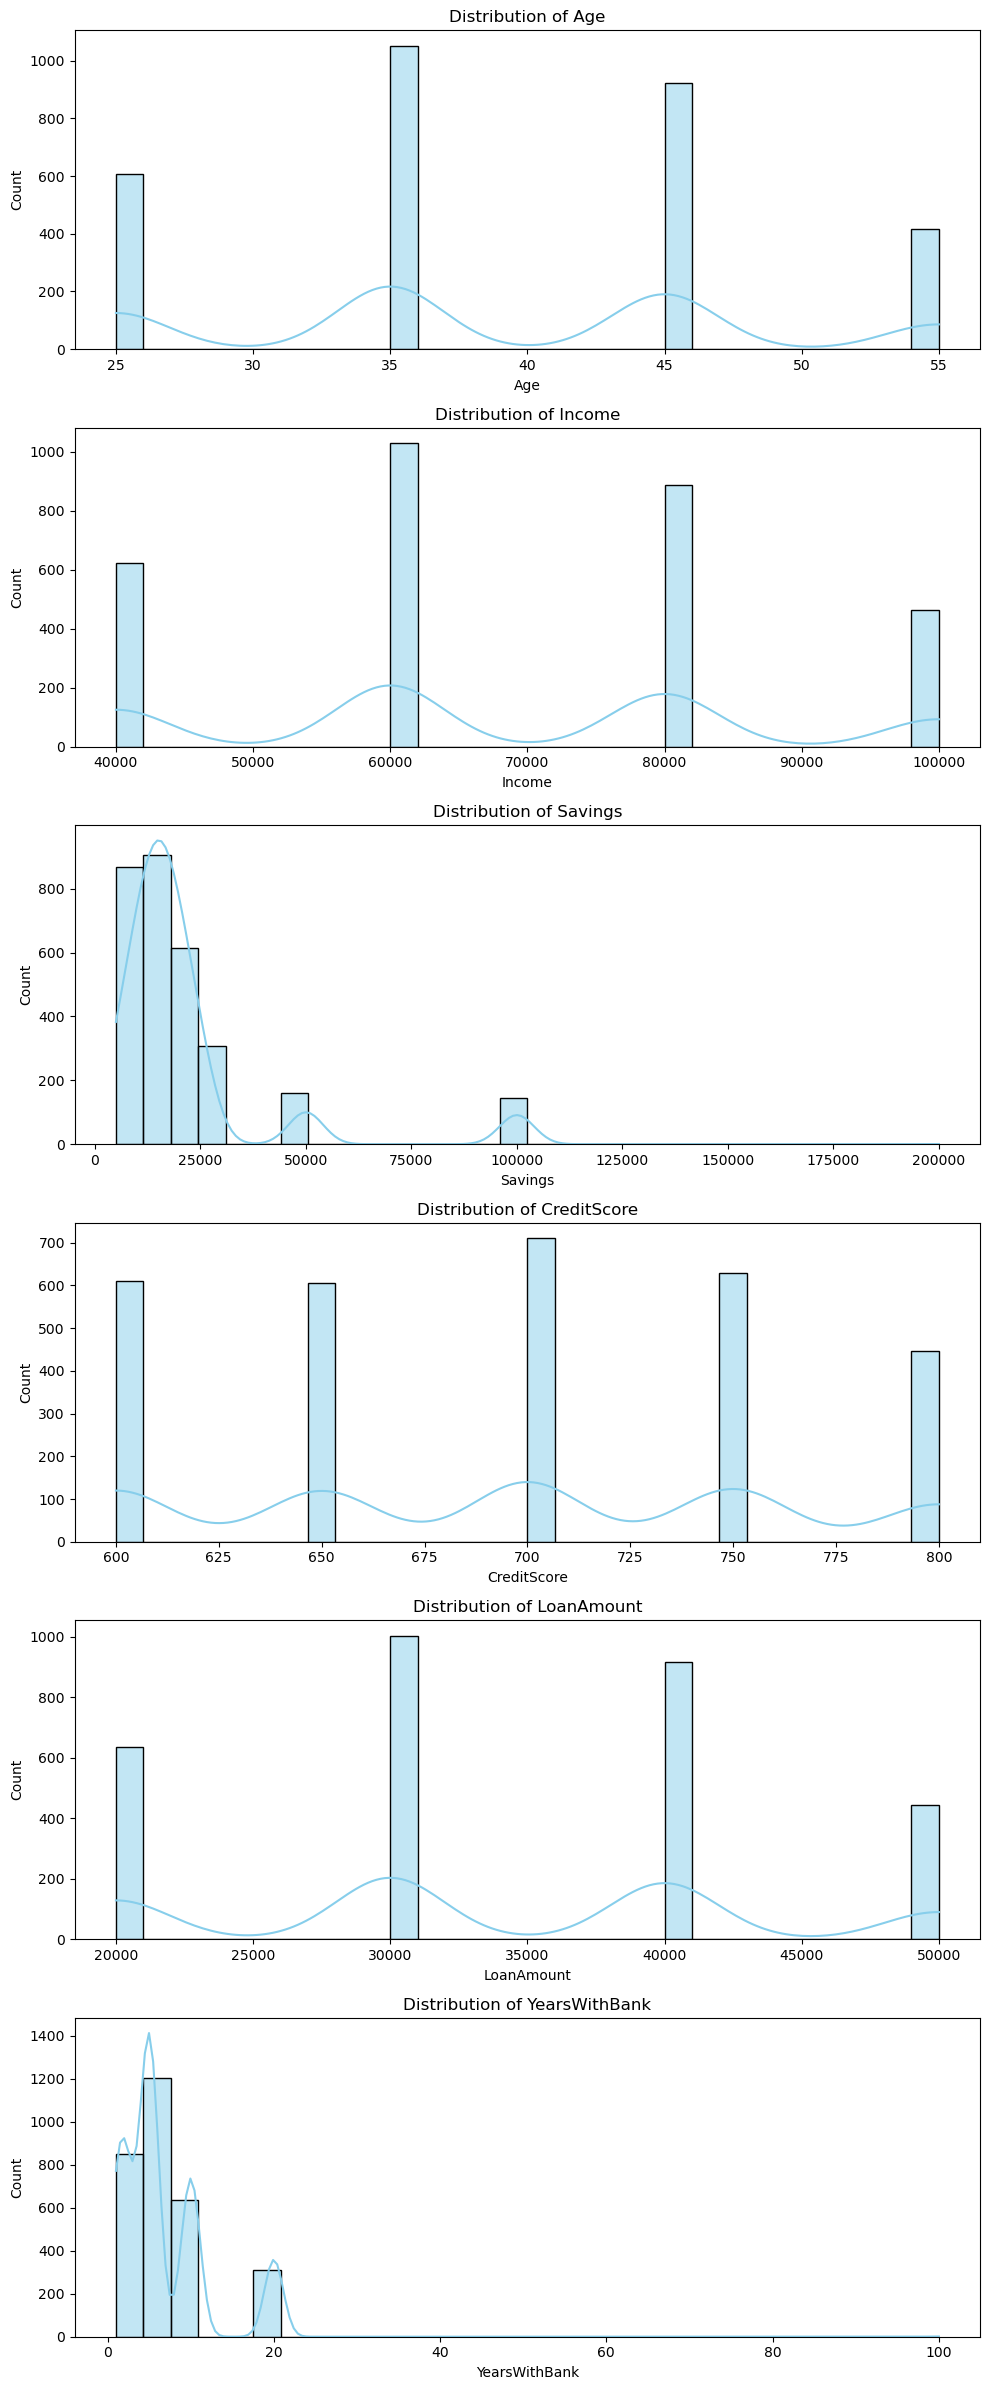

In [77]:
# Distributions for numerical columns
filtered_cols = [c for c in numerical_cols if c != 'Churn_numeric']
# Create subplots: rows = number of features, columns = 1
fig, ax = plt.subplots(len(filtered_cols), 1, figsize=(10, 4 * len(filtered_cols)))

# # Loop through the numerical_cols and plot each in a row subplot
for index, col in enumerate(filtered_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax[index], bins=30, color='skyblue')
    ax[index].set_title(f'Distribution of {col}')
    ax[index].set_xlabel(col)
    ax[index].set_ylabel('Count')

# Adjust layout
plt.tight_layout()
plt.show()

                    Age    Income   Savings  CreditScore  LoanAmount  \
Age            1.000000  0.001771 -0.018933    -0.026669    0.014527   
Income         0.001771  1.000000 -0.022101     0.016119    0.034280   
Savings       -0.018933 -0.022101  1.000000    -0.005384   -0.019301   
CreditScore   -0.026669  0.016119 -0.005384     1.000000   -0.020786   
LoanAmount     0.014527  0.034280 -0.019301    -0.020786    1.000000   
YearsWithBank  0.017199  0.021790  0.028388    -0.021149   -0.029973   
Churn_numeric -0.009083 -0.012419  0.000764     0.030831   -0.005447   

               YearsWithBank  Churn_numeric  
Age                 0.017199      -0.009083  
Income              0.021790      -0.012419  
Savings             0.028388       0.000764  
CreditScore        -0.021149       0.030831  
LoanAmount         -0.029973      -0.005447  
YearsWithBank       1.000000       0.029340  
Churn_numeric       0.029340       1.000000  


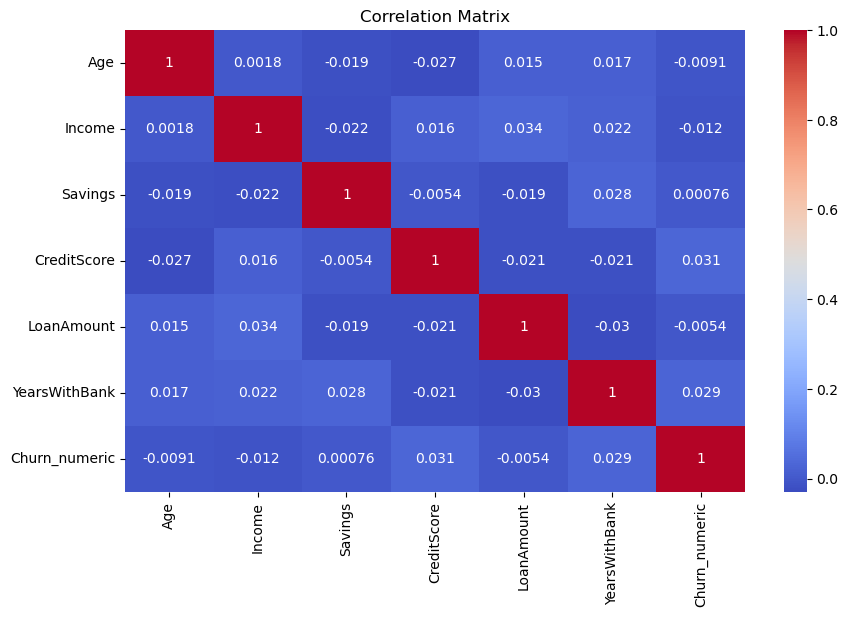

In [78]:

# Correlation matrix
corr_matrix = df[numerical_cols].corr()
print(corr_matrix)
# Visualize correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [79]:
# Selected features by Variance for numerical columns
threshold = 0.1
selector = VarianceThreshold(threshold=threshold)
selected_features = selector.fit_transform(df[numerical_cols])
print("Features selected by Variance:",selector.get_support(indices=True))

selected_columns = [numerical_cols[i] for i in selector.get_support(indices=True)]
# Columns that are NOT selected
columns_to_drop = [col for col in numerical_cols if col not in selected_columns]
#Drop the columns that are NOT selected
df_dropped = df.drop(columns=columns_to_drop, axis=1)

print("Dropped columns:", columns_to_drop)

Features selected by Variance: [0 1 2 3 4 5 6]
Dropped columns: []


In [80]:
# # X, y for information gain and random forest for numerical columns

# # These are the features we’ll select
# # X = df[['Age', 'Income','Savings' 'CreditScore', 'YearsWithBank']]
# X = df[numerical_cols.to_list()]

# # Target churn status (0 or 1)
# y = df['Churn_numeric']


In [81]:
# INFORMATION GAIN

# X = df[numerical_cols.to_list()]
X = df[[c for c in numerical_cols if c != 'Churn_numeric']]
# target churn status (0 or 1)
y = df['Churn_numeric']
info_gain = mutual_info_classif(X, y, random_state=0)
for index,gain in enumerate(info_gain):
    print(f"information Gain  for feature: {numerical_cols.to_list()[index]} is: {gain}")

inf_gain_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual_Information': info_gain
})

# Sort features by importance 
inf_gain_df = inf_gain_df.sort_values(by='Mutual_Information', ascending=False)

# Show results
inf_gain_df


information Gain  for feature: Age is: 0.00036842781319057494
information Gain  for feature: Income is: 0.0005978720012567162
information Gain  for feature: Savings is: 0.0
information Gain  for feature: CreditScore is: 0.004801951602718901
information Gain  for feature: LoanAmount is: 0.010231823789802696
information Gain  for feature: YearsWithBank is: 0.0


,Feature,Mutual_Information
4,LoanAmount,0.010232
3,CreditScore,0.004802
1,Income,0.000598
0,Age,0.000368
2,Savings,0.000000
5,YearsWithBank,0.000000


In [82]:
# RANDOM FOREST IMPORTANCE

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
feature_importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance (descending) and display results
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print("Random forest importance df:")
importance_df


Random forest importance df:


,Feature,Importance
2,Savings,0.235177
3,CreditScore,0.172602
5,YearsWithBank,0.171458
4,LoanAmount,0.147775
0,Age,0.141979
1,Income,0.131009


In [83]:
# ## CATEGORICAL STATISTICS value,counts, total percentages, ratio(churn=yes.value_counts/churn=no.value_counts) BASED ON THE TARGET
# ## MAKE A DICTIONARY to be used in visualizations based on the target (visualize the churn risk by category) 

# categories_churned_count = {}
churn_cat_statistics = {}
# categorical_cols = df.select_dtypes(include=['object']).columns

# a loop through the categorical cols in order to make a dictionary with keys the categorical columns and values usefull statistics(percentges,ratio,) based on target
# a dictionary to be used for  the visualization  
for category_key in categorical_cols:
    if category_key == 'Churn':
        continue  # Skip the target variable itself
        
    # value_counts() of every category --for instance In Gender category df[Gender].value_counts()--
    category_value_counts = df[category_key].value_counts()
    
    # value_counts() of churn YES in each specific catecorigal feature in every loop
    # example: marital_churned_counts = df[df['Churn'] == 'yes']['MaritalStatus'].value_counts()
    churned_counts = df[df['Churn'] == 'yes'][category_key].value_counts()
    
    # value_counts() of churn NO in each specific catecorigal feature in every loop
    not_churned_counts = df[df['Churn'] == 'no'][category_key].value_counts()
    
    # Dictionary to be used in visualization churn risk
    churn_cat_statistics[category_key] = {
        "churned_percentage": (churned_counts / category_value_counts * 100),
        "not_churned_pct": (not_churned_counts / category_value_counts * 100),
        "ratio": (churned_counts / not_churned_counts)
    }

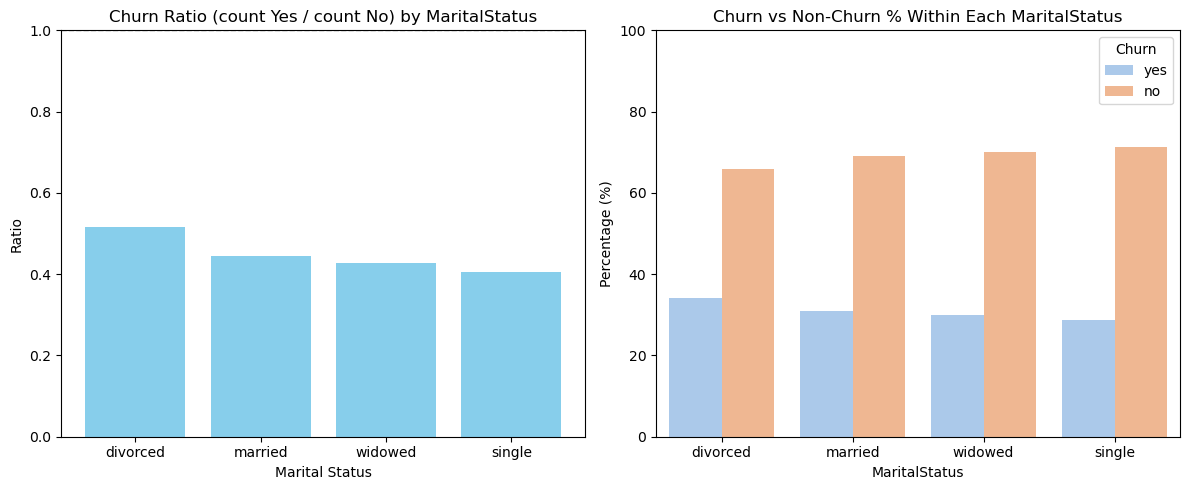

In [84]:
## VISUALIZATION churn risk of categorical column MaritalStatus

# Dataframe to be used in a bar plot visualize the ratio of those who churn YES dived with those who churn NO
# Sorted desc by Ratio = count(churn YES)/ count(churn NO)
# The greater ratio values has the greater risk to churn
marital_percentages_df = pd.DataFrame({
    # value_counts of churned/total value_counts * 100
    'churned_percentage': churn_cat_statistics['MaritalStatus']['churned_percentage'],
    'not_churned_pct': churn_cat_statistics['MaritalStatus']['not_churned_pct'],
    'Ratio': churn_cat_statistics['MaritalStatus']['ratio']
}).sort_values(by='Ratio', ascending=False)

marital_percentages_df
#               churned_percentage  not_churned_pct     Ratio
# MaritalStatus                                             
# divorced                34.074074      65.925926  0.516854
# married                 30.832646      69.167354  0.445769
# widowed                 29.900332      70.099668  0.426540
# single                  28.782895      71.217105  0.404157

## Dataframe to be used in a bar plot visualize sns barplot comparing the percentages of those who churn YES and those who churn NO for each column
marital_barplot_df = pd.DataFrame({
    'MaritalStatus': churn_cat_statistics['MaritalStatus']['churned_percentage'].index.tolist() + churn_cat_statistics['MaritalStatus'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churn_cat_statistics['MaritalStatus']['churned_percentage']) + ['no'] * len(
        churn_cat_statistics['MaritalStatus']['not_churned_pct']),
    'Percentage': churn_cat_statistics['MaritalStatus']['churned_percentage'].tolist() + churn_cat_statistics['MaritalStatus'][
        'not_churned_pct'].tolist()
})
# marital_barplot_df like:
#   MaritalStatus Churn  Percentage
# 0      divorced   yes   34.074074
# 1       married   yes   30.832646
# 2        single   yes   28.782895
# 3       widowed   yes   29.900332
# 4        single    no   71.217105
# 5       married    no   69.167354
# 6       widowed    no   70.099668
# 7      divorced    no   65.925926

marital_percentages_df

# A bar visual with the division of (count YES/ count NO) for each MaritalStatus unique value
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(marital_percentages_df.index, marital_percentages_df['Ratio'], color='skyblue')
axes[0].set_title("Churn Ratio (count Yes / count No) by MaritalStatus")
axes[0].set_ylabel("Ratio")
axes[0].set_xlabel("Marital Status")
axes[0].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylim(0, max(marital_percentages_df['Ratio'].max(), 1))

# ordered gender name(gender.value_counts().index) by ratio (Descending by greater churned YES percentage)
#in order to use this list for sorting the vvisualization barplot
sorted_Marital_order = marital_percentages_df.index.tolist()

# #Comparing the percentage of chrurned YES and percentage of churned NO by MaritalStatus unique values. 
sns.barplot(x='MaritalStatus', y='Percentage', hue='Churn', data=marital_barplot_df, ax=axes[1], palette='pastel', order=sorted_Marital_order)
axes[1].set_title("Churn vs Non-Churn % Within Each MaritalStatus")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("MaritalStatus")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


In [85]:
marital_percentages_df



,churned_percentage,not_churned_pct,Ratio
MaritalStatus,,,
divorced,34.074074,65.925926,0.516854
married,30.832646,69.167354,0.445769
widowed,29.900332,70.099668,0.426540
single,28.782895,71.217105,0.404157


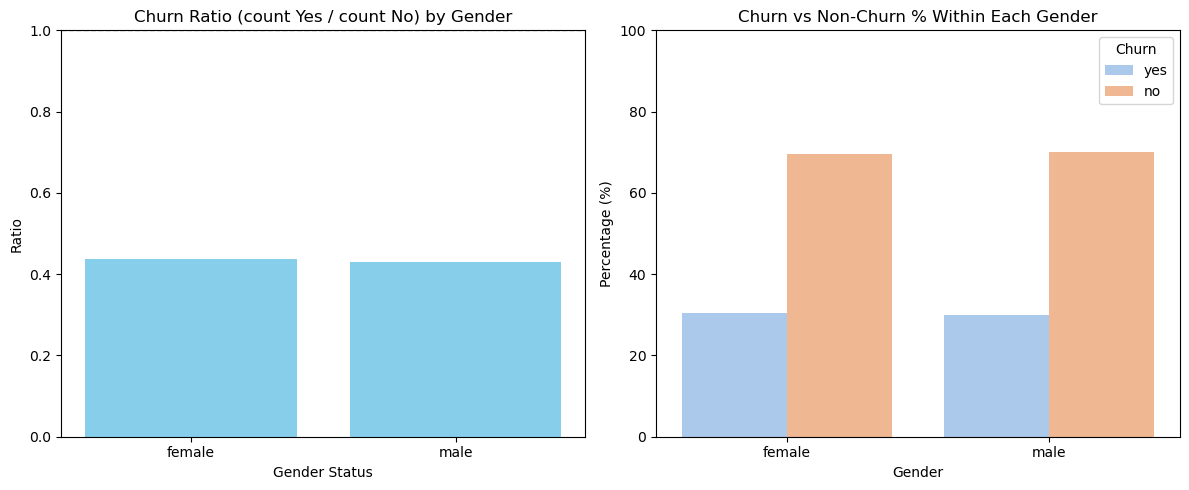

In [86]:
## VISUALIZATION churn risk of categorical column Gender

# Dataframe to be used in a bar plot visualize the ratio of those who churn YES dived with those who churn NO
# Ratio = (churn YES count/ churn NO count) sorted by Ratio Desceding
# The greater ratio values has the greater risk to churn
Gender_percentages_df = pd.DataFrame({
    'churned_percentage': churn_cat_statistics['Gender']['churned_percentage'],
    'not_churned_pct': churn_cat_statistics['Gender']['not_churned_pct'],
    'Ratio': churn_cat_statistics['Gender']['ratio']
}).sort_values(by='Ratio', ascending=False)

plot_df_gender = pd.DataFrame({
    'Gender': churn_cat_statistics['Gender']['churned_percentage'].index.tolist() + churn_cat_statistics['Gender'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churn_cat_statistics['Gender']['churned_percentage']) + ['no'] * len(
        churn_cat_statistics['Gender']['not_churned_pct']),
    'Percentage': churn_cat_statistics['Gender']['churned_percentage'].tolist() + churn_cat_statistics['Gender'][
        'not_churned_pct'].tolist()
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(Gender_percentages_df.index, Gender_percentages_df['Ratio'], color='skyblue')
axes[0].set_title("Churn Ratio (count Yes / count No) by Gender")
axes[0].set_ylabel("Ratio")
axes[0].set_xlabel("Gender Status")
axes[0].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylim(0, max(Gender_percentages_df['Ratio'].max(), 1))

# ordered gender name(gender.value_counts().index) by ratio (Descending by greater churned YES percentage)
#in order to use this list for sorting the vvisualization barplot
sorted_gender = Gender_percentages_df.index.tolist()
# #Comparing the percentage of chrurned YES and percentage of churned NO by Gender unique values. 
sns.barplot(x='Gender', y='Percentage', hue='Churn', data=plot_df_gender, ax=axes[1], palette='pastel', order=sorted_gender)
axes[1].set_title("Churn vs Non-Churn % Within Each Gender")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("Gender")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


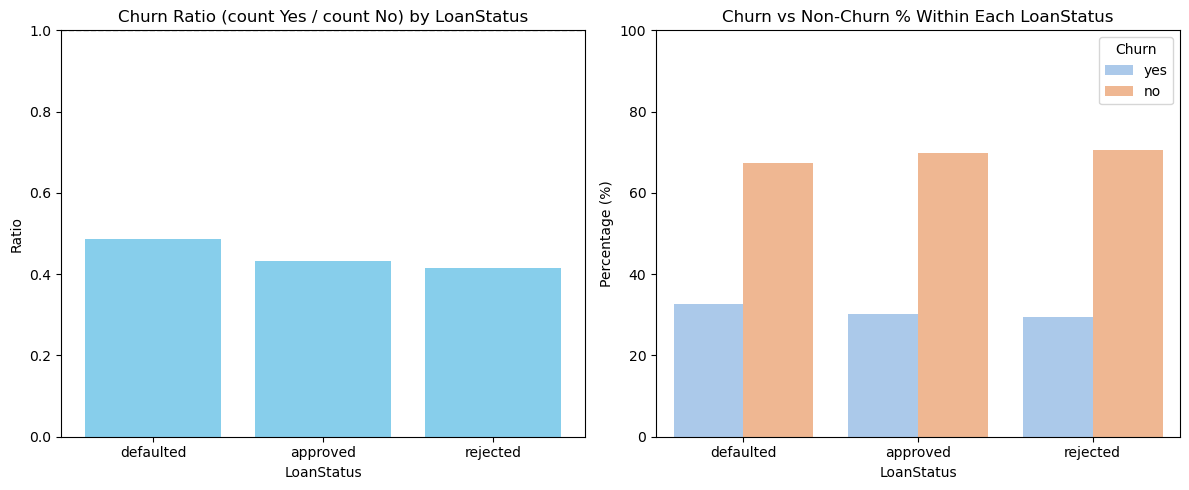

In [87]:
## VISUALIZATION churn risk of categorical column LoanStatus

# Dataframe to be used in a bar plot visualize the ratio of those who churn YES dived with those who churn NO by LoanStatus unique values
# Ratio = (churn YES count/ churn NO count) group by each LoanStatus sorted by Ratio Desceding
# The greater ratio values has the greater risk to churn
LoanStatus_percentages_df = pd.DataFrame({
    'churned_percentage': churn_cat_statistics['LoanStatus']['churned_percentage'],
    'not_churned_pct': churn_cat_statistics['LoanStatus']['not_churned_pct'],
    'Ratio': churn_cat_statistics['LoanStatus']['ratio']
}).sort_values(by='Ratio', ascending=False)

plot_df_LoanStatus= pd.DataFrame({
    'LoanStatus': churn_cat_statistics['LoanStatus']['churned_percentage'].index.tolist() + churn_cat_statistics['LoanStatus'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churn_cat_statistics['LoanStatus']['churned_percentage']) + ['no'] * len(
        churn_cat_statistics['LoanStatus']['not_churned_pct']),
    'Percentage': churn_cat_statistics['LoanStatus']['churned_percentage'].tolist() + churn_cat_statistics['LoanStatus'][
        'not_churned_pct'].tolist()
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(LoanStatus_percentages_df.index, LoanStatus_percentages_df['Ratio'], color='skyblue')
axes[0].set_title("Churn Ratio (count Yes / count No) by LoanStatus")
axes[0].set_ylabel("Ratio")
axes[0].set_xlabel("LoanStatus")
axes[0].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylim(0, max(LoanStatus_percentages_df['Ratio'].max(), 1))

# ordered LoanStatus status label(LoanStatus.value_counts().index) by ratio (Descending by greater churned YES percentage)
#in order to use this list for sorting the vvisualization barplot
sorted_LoanStatus = LoanStatus_percentages_df.index.tolist()
# #Comparing the percentage of chrurned YES and percentage of churned NO by LoanStatus unique values. 
sns.barplot(x='LoanStatus', y='Percentage', hue='Churn', data=plot_df_LoanStatus, ax=axes[1], palette='pastel', order=sorted_LoanStatus)
axes[1].set_title("Churn vs Non-Churn % Within Each LoanStatus")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("LoanStatus")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


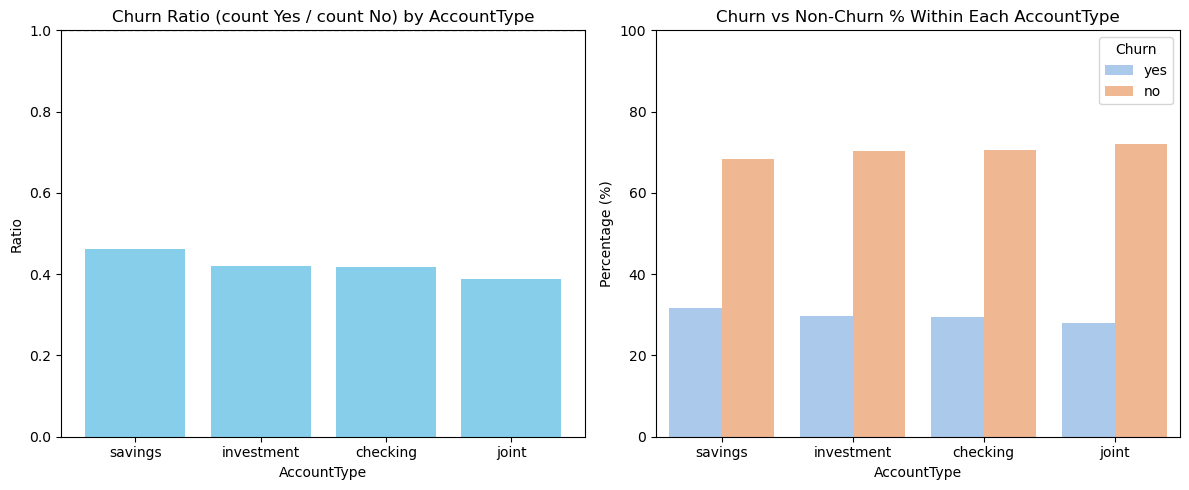

In [88]:
## VISUALIZATION churn risk of categorical column AccountType

# Dataframe to be used in a bar plot visualize the ratio of those who churn YES dived with those who churn NO
# Ratio = (churn YES count/ churn NO count) sorted by Ratio Desceding
# The greater ratio values has the greater risk to churn
AccountType_percentages_df = pd.DataFrame({
    'churned_percentage': churn_cat_statistics['AccountType']['churned_percentage'],
    'not_churned_pct': churn_cat_statistics['AccountType']['not_churned_pct'],
    'Ratio': churn_cat_statistics['AccountType']['ratio']
}).sort_values(by='Ratio', ascending=False)

plot_df_AccountType= pd.DataFrame({
    'AccountType': churn_cat_statistics['AccountType']['churned_percentage'].index.tolist() + churn_cat_statistics['AccountType'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churn_cat_statistics['AccountType']['churned_percentage']) + ['no'] * len(
        churn_cat_statistics['AccountType']['not_churned_pct']),
    'Percentage': churn_cat_statistics['AccountType']['churned_percentage'].tolist() + churn_cat_statistics['AccountType'][
        'not_churned_pct'].tolist()
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(AccountType_percentages_df.index, AccountType_percentages_df['Ratio'], color='skyblue')
axes[0].set_title("Churn Ratio (count Yes / count No) by AccountType")
axes[0].set_ylabel("Ratio")
axes[0].set_xlabel("AccountType")
axes[0].axhline(1, color='gray', linestyle='--', linewidth=1)
axes[0].set_ylim(0, max(AccountType_percentages_df['Ratio'].max(), 1))

# ordered AccountType status label(AccountType.value_counts().index) by ratio (Descending by greater churned YES percentage)
#in order to use this list for sorting the vvisualization barplot
sorted_AccountType = AccountType_percentages_df.index.tolist()
# #Comparing the percentage of chrurned YES and percentage of churned NO by AccountType unique values. 
sns.barplot(x='AccountType', y='Percentage', hue='Churn', data=plot_df_AccountType, ax=axes[1], palette='pastel', order=sorted_AccountType)
axes[1].set_title("Churn vs Non-Churn % Within Each AccountType")
axes[1].set_ylabel("Percentage (%)")
axes[1].set_xlabel("AccountType")
axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


In [89]:
# Make a dictionary with usefull statistics about the target for every numerical column to making specific dataframes to be used for visualizations 

churned_col_statistics = {}

# a loop through the categorical cols in order to make a dictionary with keys the categorical columns and values usefull statistics(percentges,ratio,) based on target
# a dictionary to be used for  the visualization  
for num_col_key in numerical_cols:
    if num_col_key == 'Churn_numeric':
        continue  # Skip the target variable itself
        
    # value_counts() of every category --for instance In Gender category df[Gender].value_counts()--
    col_value_counts = df[num_col_key].value_counts()
    
    # value_counts() of churn YES in each specific catecorigal feature in every loop
    # example: marital_churned_counts = df[df['Churn'] == 'yes']['MaritalStatus'].value_counts()
    churned_count = df[df['Churn'] == 'yes'][num_col_key].value_counts()
    
    # value_counts() of churn NO in each specific catecorigal feature in every loop
    not_churned_count = df[df['Churn'] == 'no'][num_col_key].value_counts()
    
    # Dictionary to be used in visualization churn risk
    churned_col_statistics[num_col_key] = {
        "churned_percentage": (churned_count / col_value_counts * 100),
        "not_churned_pct": (not_churned_count / col_value_counts * 100),
        "ratio": (churned_count / not_churned_count)
    }

          churned_percentage  not_churned_pct     Ratio      cols
Savings                                                          
50000.0            35.220126        64.779874  0.543689   50000.0
20000.0            31.973899        68.026101  0.470024   20000.0
10000.0            30.560272        69.439728  0.440098   10000.0
25000.0            30.097087        69.902913  0.430556   25000.0
15000.0            29.249448        70.750552  0.413417   15000.0
100000.0           27.586207        72.413793  0.380952  100000.0
5000.0             27.338129        72.661871  0.376238    5000.0
200000.0                 NaN       100.000000       NaN  200000.0


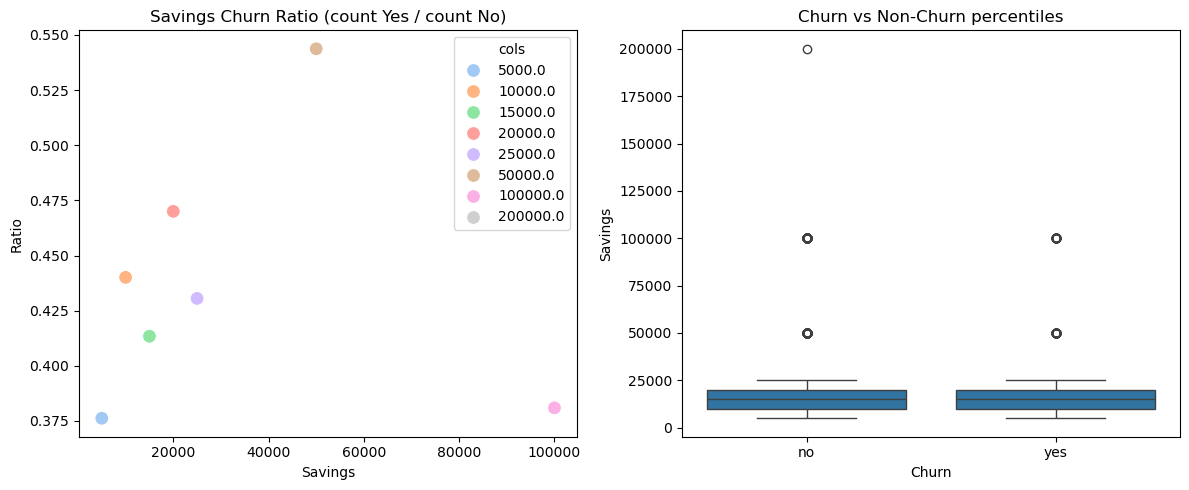

In [90]:
## VISUALIZATION churn risk of numerical column Savings

# Dataframe to be used in a scatter plot visualize the ratio of those who churn YES dived with those who churn NO
# Sorted desc by Ratio = count(churn YES)/ count(churn NO)
# The greater ratio values has the greater risk to churn
savings_percentage_df = pd.DataFrame({
    'churned_percentage': churned_col_statistics['Savings']['churned_percentage'],
    'not_churned_pct': churned_col_statistics['Savings']['not_churned_pct'],
    'Ratio': churned_col_statistics['Savings']['ratio']
}).sort_values(by='Ratio', ascending=False)

savings_percentage_df['cols'] = savings_percentage_df.index.tolist()
print(savings_percentage_df)

## Dataframe to be used in a box plot, visualize sns boxplot comparing values who churn YES and values who churn NO
savings_boxplotdf = pd.DataFrame({
    'Savings': churned_col_statistics['Savings']['churned_percentage'].index.tolist() + churned_col_statistics['Savings'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churned_col_statistics['Savings']['churned_percentage']) + ['no'] * len(
        churned_col_statistics['Savings']['not_churned_pct']),
    'Percentage': churned_col_statistics['Savings']['churned_percentage'].tolist() + churned_col_statistics['Savings'][
        'not_churned_pct'].tolist()
})


# A bar visual with the division of (count YES/ count NO) for each Savings values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='cols', y='Ratio', hue='cols', data=savings_percentage_df, ax=axes[0], palette='pastel', s=100)
axes[0].set_title("Savings Churn Ratio (count Yes / count No)")
axes[0].set_xlabel("Savings")
axes[0].set_ylabel("Ratio")

sns.boxplot(x='Churn', y='Savings', data=df)
axes[1].set_title("Churn vs Non-Churn percentiles")
axes[1].set_ylabel("Savings")
axes[1].set_xlabel("Churn")
# axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


             churned_percentage  not_churned_pct     Ratio   cols
CreditScore                                                      
800.0                 32.286996        67.713004  0.476821  800.0
750.0                 32.006369        67.993631  0.470726  750.0
650.0                 31.074380        68.925620  0.450839  650.0
700.0                 28.832630        71.167370  0.405138  700.0
600.0                 27.540984        72.459016  0.380090  600.0


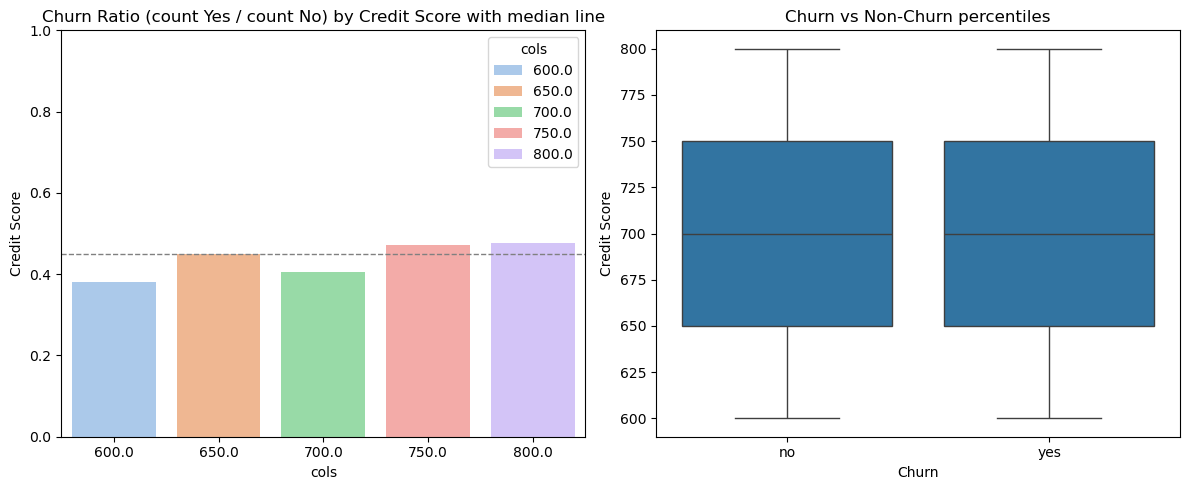

In [91]:
## VISUALIZATION churn risk of numerical column creditScore

# Dataframe to be used in a bar plot visualize the ratio of those who churn YES dived with those who churn NO
# Sorted desc by Ratio = count(churn YES)/ count(churn NO)
# The greater ratio values has the greater risk to churn
creditScore_percentage_df = pd.DataFrame({
    'churned_percentage': churned_col_statistics['CreditScore']['churned_percentage'],
    'not_churned_pct': churned_col_statistics['CreditScore']['not_churned_pct'],
    'Ratio': churned_col_statistics['CreditScore']['ratio']
}).sort_values(by='Ratio', ascending=False)

creditScore_percentage_df['cols'] = creditScore_percentage_df.index.tolist()
print(creditScore_percentage_df)

## Dataframe to be used in a bar plot visualize boxplot comparing those who churn YES and those who churn NO for each numerical column on y axis
crdScore_boxplotdf = pd.DataFrame({
    'CreditScore': churned_col_statistics['CreditScore']['churned_percentage'].index.tolist() + churned_col_statistics['CreditScore'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churned_col_statistics['CreditScore']['churned_percentage']) + ['no'] * len(
        churned_col_statistics['CreditScore']['not_churned_pct']),
    'Percentage': churned_col_statistics['CreditScore']['churned_percentage'].tolist() + churned_col_statistics['CreditScore'][
        'not_churned_pct'].tolist()
})


# A bar visual with the division of (count YES/ count NO) for each CreditScore unique value
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# # sns.barplot(data=creditScore_percentage_df, x='cols', y="Ratio" hue = 'cols')
# # axes[0].bar( creditScore_percentage_df.index.tolist(),creditScore_percentage_df['Ratio'], color='skyblue')
sns.barplot(x='cols', y='Ratio', hue='cols', data=creditScore_percentage_df, ax=axes[0], palette='pastel')
axes[0].set_title("Churn Ratio (count Yes / count No) by Credit Score with median line")
axes[0].set_ylabel("Ratio")
axes[0].set_ylabel("Credit Score")
axes[0].axhline(creditScore_percentage_df.Ratio.median(), color='gray', linestyle='--', linewidth=1)
axes[0].set_ylim(0, max(creditScore_percentage_df['Ratio'].max(), 1))

# #Comparing the percentage of chrurned YES and percentage of churned NO by MaritalStatus values. 
sns.boxplot(x='Churn', y='CreditScore', data=df)
axes[1].set_title("Churn vs Non-Churn percentiles")
axes[1].set_ylabel("Credit Score")
axes[1].set_xlabel("Churn")
# axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [92]:
savings_percentage_df

,churned_percentage,not_churned_pct,Ratio,cols
Savings,,,,
50000.0,35.220126,64.779874,0.543689,50000.0
20000.0,31.973899,68.026101,0.470024,20000.0
10000.0,30.560272,69.439728,0.440098,10000.0
25000.0,30.097087,69.902913,0.430556,25000.0
15000.0,29.249448,70.750552,0.413417,15000.0
100000.0,27.586207,72.413793,0.380952,100000.0
5000.0,27.338129,72.661871,0.376238,5000.0
200000.0,NaN,100.000000,NaN,200000.0


            churned_percentage  not_churned_pct     Ratio     cols
LoanAmount                                                        
40000.0              31.406761        68.593239  0.457870  40000.0
30000.0              30.278884        69.721116  0.434286  30000.0
20000.0              29.921260        70.078740  0.426966  20000.0
50000.0              27.927928        72.072072  0.387500  50000.0


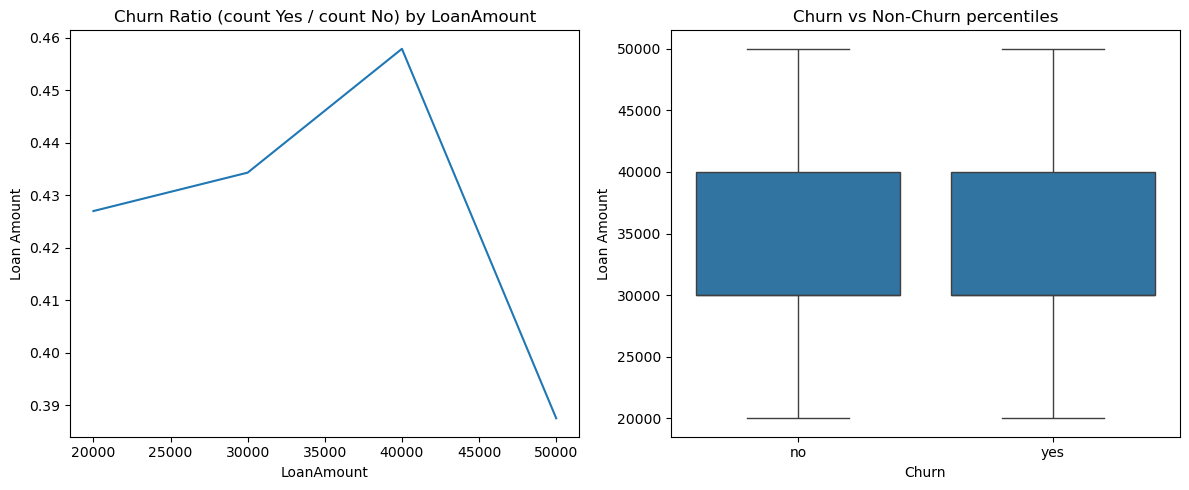

In [93]:
## VISUALIZATION churn risk of numerical column LoanAmount

# Dataframe to be used in a line plot visualize the ratio of those who churn YES dived with those who churn NO
# Sorted desc by Ratio = count(churn YES)/ count(churn NO)
# The greater ratio values has the greater risk to churn
LoanAmount_percentage_df = pd.DataFrame({
    'churned_percentage': churned_col_statistics['LoanAmount']['churned_percentage'],
    'not_churned_pct': churned_col_statistics['LoanAmount']['not_churned_pct'],
    'Ratio': churned_col_statistics['LoanAmount']['ratio']
}).sort_values(by='Ratio', ascending=False)

LoanAmount_percentage_df['cols'] = LoanAmount_percentage_df.index.tolist()
print(LoanAmount_percentage_df)

## Dataframe to be used in a bar plot visualize boxplot comparing those who churn YES and those who churn NO for each numerical column on y axis
loan_boxplotdf = pd.DataFrame({
    'LoanAmount': churned_col_statistics['LoanAmount']['churned_percentage'].index.tolist() + churned_col_statistics['LoanAmount'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churned_col_statistics['LoanAmount']['churned_percentage']) + ['no'] * len(
        churned_col_statistics['LoanAmount']['not_churned_pct']),
    'Percentage': churned_col_statistics['LoanAmount']['churned_percentage'].tolist() + churned_col_statistics['LoanAmount'][
        'not_churned_pct'].tolist()
})


# A line visual with the division of (count YES/ count NO) for each LoanAmount value
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# sns.scatterplot(x='cols', y='Ratio', hue='cols', data=LoanAmount_percentage_df, ax=axes[0], palette='pastel', s=100)
sns.lineplot(data=LoanAmount_percentage_df, x=LoanAmount_percentage_df.index, y="Ratio",ax=axes[0])
axes[0].set_title("Churn Ratio (count Yes / count No) by LoanAmount")
axes[0].set_ylabel("Ratio")
axes[0].set_ylabel("Loan Amount")

# #Comparing boxplot chrurned YES and boxplot of churned NO for LoanAmount. 
sns.boxplot(x='Churn', y='LoanAmount', data=df)
axes[1].set_title("Churn vs Non-Churn percentiles")
axes[1].set_ylabel("Loan Amount")
axes[1].set_xlabel("Churn")
# axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()


               churned_percentage  not_churned_pct     Ratio   cols
YearsWithBank                                                      
20.0                    37.419355        62.580645  0.597938   20.0
2.0                     32.347826        67.652174  0.478149    2.0
5.0                     29.343308        70.656692  0.415294    5.0
10.0                    27.786499        72.213501  0.384783   10.0
1.0                     27.007299        72.992701  0.370000    1.0
100.0                         NaN       100.000000       NaN  100.0


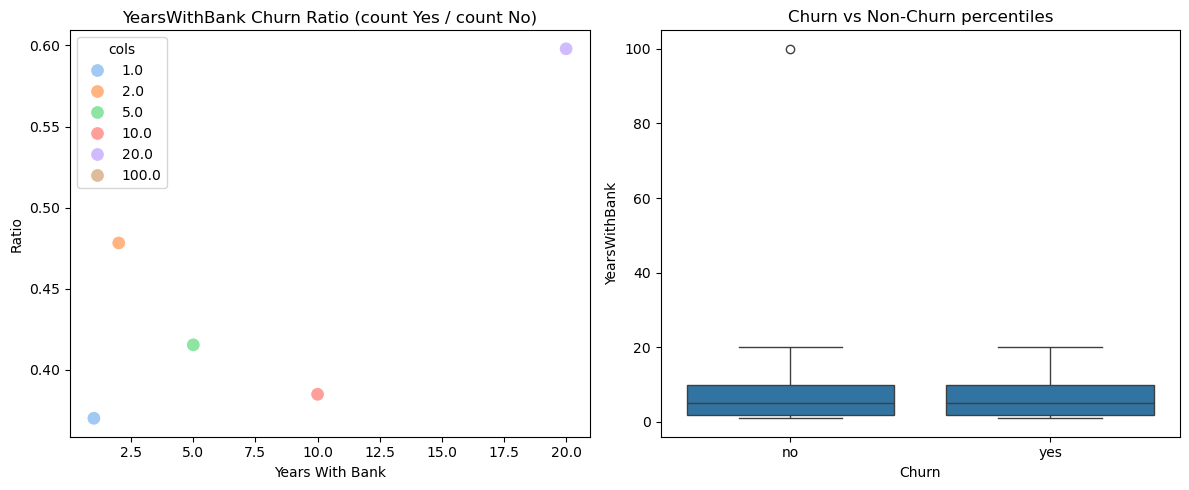

In [94]:
## VISUALIZATION churn risk of numerical column YearsWithBank

# Dataframe to be used in a scatter plot visualize the ratio of those who churn YES dived with those who churn NO
# Sorted desc by Ratio = count(churn YES)/ count(churn NO)
# The greater ratio values has the greater risk to churn
years_percentage_df = pd.DataFrame({
    'churned_percentage': churned_col_statistics['YearsWithBank']['churned_percentage'],
    'not_churned_pct': churned_col_statistics['YearsWithBank']['not_churned_pct'],
    'Ratio': churned_col_statistics['YearsWithBank']['ratio']
}).sort_values(by='Ratio', ascending=False)

years_percentage_df['cols'] = years_percentage_df.index.tolist()
print(years_percentage_df)

## Dataframe to be used in a box plot, visualize sns boxplot comparing values who churn YES and values who churn NO
years_boxplotdf = pd.DataFrame({
    'YearsWithBank': churned_col_statistics['YearsWithBank']['churned_percentage'].index.tolist() + churned_col_statistics['YearsWithBank'][
        'not_churned_pct'].index.tolist(),
    'Churn': ['yes'] * len(churned_col_statistics['YearsWithBank']['churned_percentage']) + ['no'] * len(
        churned_col_statistics['YearsWithBank']['not_churned_pct']),
    'Percentage': churned_col_statistics['YearsWithBank']['churned_percentage'].tolist() + churned_col_statistics['YearsWithBank'][
        'not_churned_pct'].tolist()
})


# A bar visual with the division of (count YES/ count NO) for each YearsWithBank values
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x='cols', y='Ratio', hue='cols', data=years_percentage_df, ax=axes[0], palette='pastel', s=100)
axes[0].set_title("YearsWithBank Churn Ratio (count Yes / count No)")
axes[0].set_xlabel("Years With Bank")
axes[0].set_ylabel("Ratio")

sns.boxplot(x='Churn', y='YearsWithBank', data=df)
axes[1].set_title("Churn vs Non-Churn percentiles")
axes[1].set_ylabel("YearsWithBank")
axes[1].set_xlabel("Churn")
# axes[1].set_ylim(0, 100)
plt.tight_layout()
plt.show()

In [95]:
df.columns = df.columns.str.lower()
df.columns
df.to_csv('datasets/final_dataset.csv', index=False)
